# NYSE TAQ Consolidated Trades Exploration

This notebook walks through the consolidated full-day trades file from the NYSE TAQ sample:

- `EQY_US_ALL_TRADE_20260102.gz`

We will:
1. Inspect the raw schema and a few rows.
2. Sample the file to understand symbol coverage.
3. Build symbol-minute feature bars for selected tickers.
4. Visualize intraday volume and volatility profiles.
5. Demonstrate how these curves can feed into dimension-reduction experiments.

**Note:** The compressed file is ~3.2 GB. The notebook uses streaming / sampling so it does not load everything into memory.

In [1]:
from pathlib import Path
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

DATA_DIR = Path('../data/nyse_taq_samples')
RESEARCH_DIR = Path('.')

TRADE_PATH = DATA_DIR / 'EQY_US_ALL_TRADE_20260102.gz'
REF_PATH = DATA_DIR / 'EQY_US_ALL_REF_MASTER_20260102.gz'

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

print('Consolidated trade file exists:', TRADE_PATH.exists())
print('Reference master exists:', REF_PATH.exists())

Consolidated trade file exists: True
Reference master exists: True


## 1. What the file is

`EQY_US_ALL_TRADE_20260102.gz` is the **consolidated full-day trade file** for January 2, 2026.

- It contains trades from **all reporting venues**, not just the NYSE floor.
- Each row is one executed trade print.
- Timestamps are nanosecond precision.
- It is pipe-delimited (`|`) with a header row.

In [2]:
def peek_gz(path, n=5):
    with gzip.open(path, 'rt', encoding='latin-1', errors='replace') as f:
        header = f.readline().strip().split('|')
        rows = [f.readline().strip().split('|') for _ in range(n)]
    return header, rows

header, first_rows = peek_gz(TRADE_PATH, 5)
print('Columns:', header)
print()
for i, row in enumerate(first_rows):
    print(f'Row {i+1}:', row)

Columns: ['Time', 'Exchange', 'Symbol', 'Sale Condition', 'Trade Volume', 'Trade Price', 'Trade Stop Stock Indicator', 'Trade Correction Indicator', 'Sequence Number', 'Trade Id', 'Source of Trade', 'Trade Reporting Facility', 'Participant Timestamp', 'Trade Reporting Facility TRF Timestamp', 'Trade Through Exempt Indicator']

Row 1: ['041930940885651', 'P', 'A', '  TI', '1', '137.29', 'N', '00', '4005', '52983525029425', 'C', '', '041930940851589', '', '0']
Row 2: ['041930945218960', 'P', 'A', '  TI', '6', '137.19', 'N', '00', '4006', '52983525029426', 'C', '', '041930945195853', '', '0']
Row 3: ['044637030120042', 'T', 'A', '  TI', '1', '136.21', 'N', '00', '4368', '62879130799192', 'C', '', '044637029763969', '', '0']
Row 4: ['050732481979841', 'K', 'A', '  TI', '1', '137', 'N', '00', '4648', '52983525028952', 'C', '', '050732481723000', '', '0']
Row 5: ['052359160985600', 'P', 'A', '  TI', '5', '136.21', 'N', '00', '4904', '52983525033806', 'C', '', '052359160960394', '', '0']


## 2. Column meanings

| Column | Meaning | Feature-engineering use |
|---|---|---|
| `Time` | Trade timestamp (nanoseconds since midnight UTC, HHMMSSNNNNNNNNN) | Build time bins, minute bars, intraday profiles |
| `Exchange` | Reporting venue code (P=NYSE, T=FINRA, K=ISE, etc.) | Venue fragmentation, market-share analysis |
| `Symbol` | Ticker symbol | Universe grouping, symbol filtering |
| `Sale Condition` | Trade condition flags (e.g., `TI` = trade through intermarket) | Filter regular trades, identify special prints |
| `Trade Volume` | Shares traded | Volume, trade size, dollar volume |
| `Trade Price` | Execution price | VWAP, returns, volatility, price impact |
| `Trade Stop Stock Indicator` | Stop stock indicator | Usually not needed for basic features |
| `Trade Correction Indicator` | Correction flag | Drop or correct bad prints |
| `Sequence Number` | Message sequence | Detect gaps, ordering |
| `Trade Id` | Unique trade identifier | Deduplication |
| `Source of Trade` | Trade source | Venue/liquidity-source analysis |
| `Trade Reporting Facility` | TRF code | OTC / dark-pool routing information |
| `Participant Timestamp` | Participant-reported timestamp | Latency analysis |
| `Trade Reporting Facility TRF Timestamp` | TRF timestamp | Latency analysis |
| `Trade Through Exempt Indicator` | Trade-through exemption flag | Regulatory / special-condition flag |

## 3. Sample the file to understand coverage

The full file is too large to load at once. We scan a sample of rows and count symbols.
This gives a sense of which tickers are most active and how many distinct symbols appear.

**Important discovery:** this file is **sorted alphabetically by symbol**. The first 100k rows contain mostly symbols starting with `A`. That means if you want symbols like `TSLA` or `VXX`, the parser must scan much farther into the file (potentially the whole 3.2 GB).

In [3]:
def sample_trade_symbols(path, max_rows=2_000_000):
    """Stream through the first max_rows trade lines and count symbols."""
    counts = Counter()
    total = 0
    with gzip.open(path, 'rt', encoding='latin-1', errors='replace') as f:
        next(f)  # skip header
        for line in f:
            parts = line.strip().split('|')
            if len(parts) < 6:
                continue
            counts[parts[2]] += 1
            total += 1
            if total >= max_rows:
                break
    return counts, total

symbol_counts, n_rows = sample_trade_symbols(TRADE_PATH, max_rows=2_000_000)
print(f'Rows scanned: {n_rows:,}')
print(f'Unique symbols in sample: {len(symbol_counts):,}')
print()
print('Top 20 symbols by trade count in sample:')
for sym, c in symbol_counts.most_common(20):
    print(f'  {sym:8s} {c:>8,}')

Rows scanned: 2,000,000
Unique symbols in sample: 154

Top 20 symbols by trade count in sample:
  AAPL      642,197
  ACHR       94,768
  AAL        88,562
  ACN        74,290
  ABT        74,204
  AA         71,969
  ABNB       65,130
  ABBV       61,712
  ADBE       50,665
  AAOI       48,697
  ACWI       40,804
  ACI        35,971
  AAP        32,135
  ACGL       30,138
  ACVA       29,221
  ACHC       28,357
  A          26,692
  AAPU       25,891
  ACMR       25,308
  AAON       24,770


## 4. Build symbol-minute bars for selected tickers

We scan the file and aggregate trades into one-minute bars for a small set of liquid tickers.
This is the same idea as the existing `taq_consolidated_trade_bars.csv`, but here we show the full pipeline.

If you want more symbols, add them to `target_symbols`. Because the file is sorted alphabetically, symbols starting with `T`/`V`/`X` require scanning almost the entire 3.2 GB file. For a quick demo, use the commented-out `A`-name set.

In [4]:
target_symbols = {
    'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'TSLA', 'META', 'NVDA',
    'SPY', 'QQQ', 'IWM', 'DIA', 'VXX',
    'JPM', 'XOM', 'JNJ', 'UNH', 'HD', 'PG'
}

# Fast demo option: the file is sorted alphabetically, so A-names appear first.
# Uncomment the next line to scan quickly; keep the line above for a full scan.
# target_symbols = {'A', 'AA', 'AAAU', 'AACG', 'AADR'}  # fast demo

def parse_time_ns(time_str):
    """Convert HHMMSSNNNNNNNNN string to minute-of-day integer."""
    try:
        hours = int(time_str[:2])
        minutes = int(time_str[2:4])
        return hours * 60 + minutes
    except Exception:
        return np.nan

def build_minute_bars(path, target_symbols, max_scan_rows=None):
    """Stream trades and keep only rows whose symbol is in target_symbols.
    
    max_scan_rows = None means scan the entire file. For late-alphabet symbols
    this may take a few minutes because the consolidated trade file is ~3.2 GB.
    """
    rows = []
    scanned = 0
    with gzip.open(path, 'rt', encoding='latin-1', errors='replace') as f:
        next(f)  # skip header
        for line in f:
            parts = line.strip().split('|')
            if len(parts) < 6:
                continue
            symbol = parts[2]
            if symbol not in target_symbols:
                scanned += 1
                if max_scan_rows and scanned >= max_scan_rows:
                    break
                continue
            try:
                minute = parse_time_ns(parts[0])
                volume = int(parts[4])
                price = float(parts[5])
                sale_cond = parts[3].strip()
            except Exception:
                continue
            if np.isnan(minute) or volume <= 0 or price <= 0:
                continue
            rows.append({
                'symbol': symbol,
                'time_bin': int(minute),
                'volume': volume,
                'price': price,
                'sale_cond': sale_cond,
            })
            scanned += 1
            if max_scan_rows and scanned >= max_scan_rows:
                break
    return pd.DataFrame(rows)

# NOTE: scanning the full file for late-alphabet symbols can take ~5-10 minutes.
trade_df = build_minute_bars(TRADE_PATH, target_symbols, max_scan_rows=None)
print(f'Target-symbol trades parsed: {len(trade_df):,}')
print(f'Symbols found: {trade_df["symbol"].nunique()}')
trade_df.head()

Target-symbol trades parsed: 10,376,289
Symbols found: 17


,symbol,time_bin,volume,price,sale_cond
0,AAPL,240,1,272.17,@ TI
1,AAPL,240,5,272.64,@ TI
2,AAPL,240,50,272.50,@ TI
3,AAPL,240,2,272.60,@ TI
4,AAPL,240,1,272.64,@ TI


In [9]:
trade_df


,symbol,time_bin,volume,price,sale_cond
0,AAPL,240,1,272.17,@ TI
1,AAPL,240,5,272.64,@ TI
2,AAPL,240,50,272.50,@ TI
3,AAPL,240,2,272.60,@ TI
4,AAPL,240,1,272.64,@ TI
...,...,...,...,...,...
10376284,XOM,1197,17,122.65,TI
10376285,XOM,1197,3,122.64,TI
10376286,XOM,1199,10,122.65,TI
10376287,XOM,1199,20,122.64,TI


In [5]:
def aggregate_bars(df):
    """Aggregate trade records into symbol-minute OHLC bars."""
    bars = df.groupby(['symbol', 'time_bin']).agg(
        total_volume=('volume', 'sum'),
        trade_count=('volume', 'count'),
        open_price=('price', 'first'),
        high_price=('price', 'max'),
        low_price=('price', 'min'),
        close_price=('price', 'last'),
        vwap=('price', lambda x: np.average(x, weights=df.loc[x.index, 'volume'])),
        avg_price=('price', 'mean'),
        avg_volume=('volume', 'mean'),
        max_volume=('volume', 'max'),
    ).reset_index()
    
    bars['minute_return'] = bars.groupby('symbol').apply(
        lambda g: np.log(g['close_price']) - np.log(g['close_price'].shift(1))
    ).reset_index(level=0, drop=True)
    
    bars['minute_range'] = np.log(bars['high_price']) - np.log(bars['low_price'])
    bars['realized_var'] = bars['minute_return'] ** 2
    bars['dollar_volume'] = bars['total_volume'] * bars['vwap']
    
    # Some minutes may be missing (no trades). Keep them as NaN where appropriate.
    bars['hour'] = bars['time_bin'] // 60
    bars['minute_of_hour'] = bars['time_bin'] % 60
    
    return bars

bars = aggregate_bars(trade_df)
bars.head()

/var/folders/p5/f7r_yk0172xdcy6vqz0hvnwm0000gp/T/ipykernel_15905/1584283932.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bars['minute_return'] = bars.groupby('symbol').apply(


,symbol,time_bin,total_volume,trade_count,open_price,high_price,low_price,close_price,vwap,avg_price,avg_volume,max_volume,minute_return,minute_range,realized_var,dollar_volume,hour,minute_of_hour
0,AAPL,240,1788,75,272.17,273.30,272.17,273.08,273.176326,273.070667,23.840000,165,NaN,0.004143,NaN,488439.27,4,0
1,AAPL,241,791,39,273.29,273.90,273.24,273.50,273.410164,273.448974,20.282051,100,0.001537,0.002413,2.361844e-06,216267.44,4,1
2,AAPL,242,12,6,273.25,273.32,273.25,273.32,273.302500,273.295000,2.000000,4,-0.000658,0.000256,4.334273e-07,3279.63,4,2
3,AAPL,243,66,8,273.32,273.32,273.30,273.30,273.319091,273.315000,8.250000,22,-0.000073,0.000073,5.354870e-09,18039.06,4,3
4,AAPL,244,74,10,273.34,273.42,273.32,273.40,273.371622,273.358000,7.400000,30,0.000366,0.000366,1.338326e-07,20229.50,4,4


## 5. Daily summary per symbol

A quick cross-sectional view of trading activity on this sample day.

In [6]:
summary = bars.groupby('symbol').agg(
    total_volume=('total_volume', 'sum'),
    total_trades=('trade_count', 'sum'),
    avg_trade_size=('avg_volume', 'mean'),
    vwap=('vwap', lambda x: np.average(x, weights=bars.loc[x.index, 'total_volume'])),
    open_price=('open_price', 'first'),
    close_price=('close_price', 'last'),
    realized_var=('realized_var', 'sum'),
    dollar_volume=('dollar_volume', 'sum'),
).reset_index()

summary['daily_return_pct'] = 100 * np.log(summary['close_price'] / summary['open_price'])
summary['realized_vol'] = np.sqrt(summary['realized_var'])
summary = summary.sort_values('total_trades', ascending=False)
summary

,symbol,total_volume,total_trades,avg_trade_size,vwap,open_price,close_price,realized_var,dollar_volume,daily_return_pct,realized_vol
9,NVDA,160469650,2260614,125.993951,189.829647,189.45,188.9800,0.000726,3.046190e+10,-0.248395,0.026935
13,TSLA,89922555,1865256,56.745168,443.864800,458.63,441.4900,0.000511,3.991346e+10,-3.808842,0.022599
12,SPY,93459938,1251787,1163.424969,682.980148,685.32,683.1700,0.000120,6.383128e+10,-0.314215,0.010965
11,QQQ,62536678,1088613,76.464396,614.899592,617.38,613.6900,0.000119,3.845378e+10,-0.599480,0.010927
1,AMZN,56867853,750800,92.105621,227.916564,232.56,226.6400,0.000607,1.296113e+10,-2.578540,0.024632
8,MSFT,29352772,716532,41.511162,474.412569,487.00,473.3000,0.005342,1.392532e+10,-2.853469,0.073089
0,AAPL,48835599,642197,103.375618,271.727426,272.17,270.9607,0.000185,1.326997e+10,-0.445308,0.013602
7,META,15197729,423555,44.817745,651.685163,664.50,649.8600,0.011064,9.904135e+09,-2.227792,0.105184
4,IWM,42081335,351334,1229.803705,247.682018,247.70,248.7800,0.000360,1.042279e+10,0.435064,0.018971
14,UNH,9464620,181261,541.089411,335.686209,330.53,336.6200,0.007092,3.177142e+09,1.825727,0.084216


## 6. Intraday volume and volatility profiles

These curves show how activity evolves over the trading day. They are the natural inputs for a dimension-reduction experiment: each symbol-day becomes a vector of minute-by-minute volume or volatility.

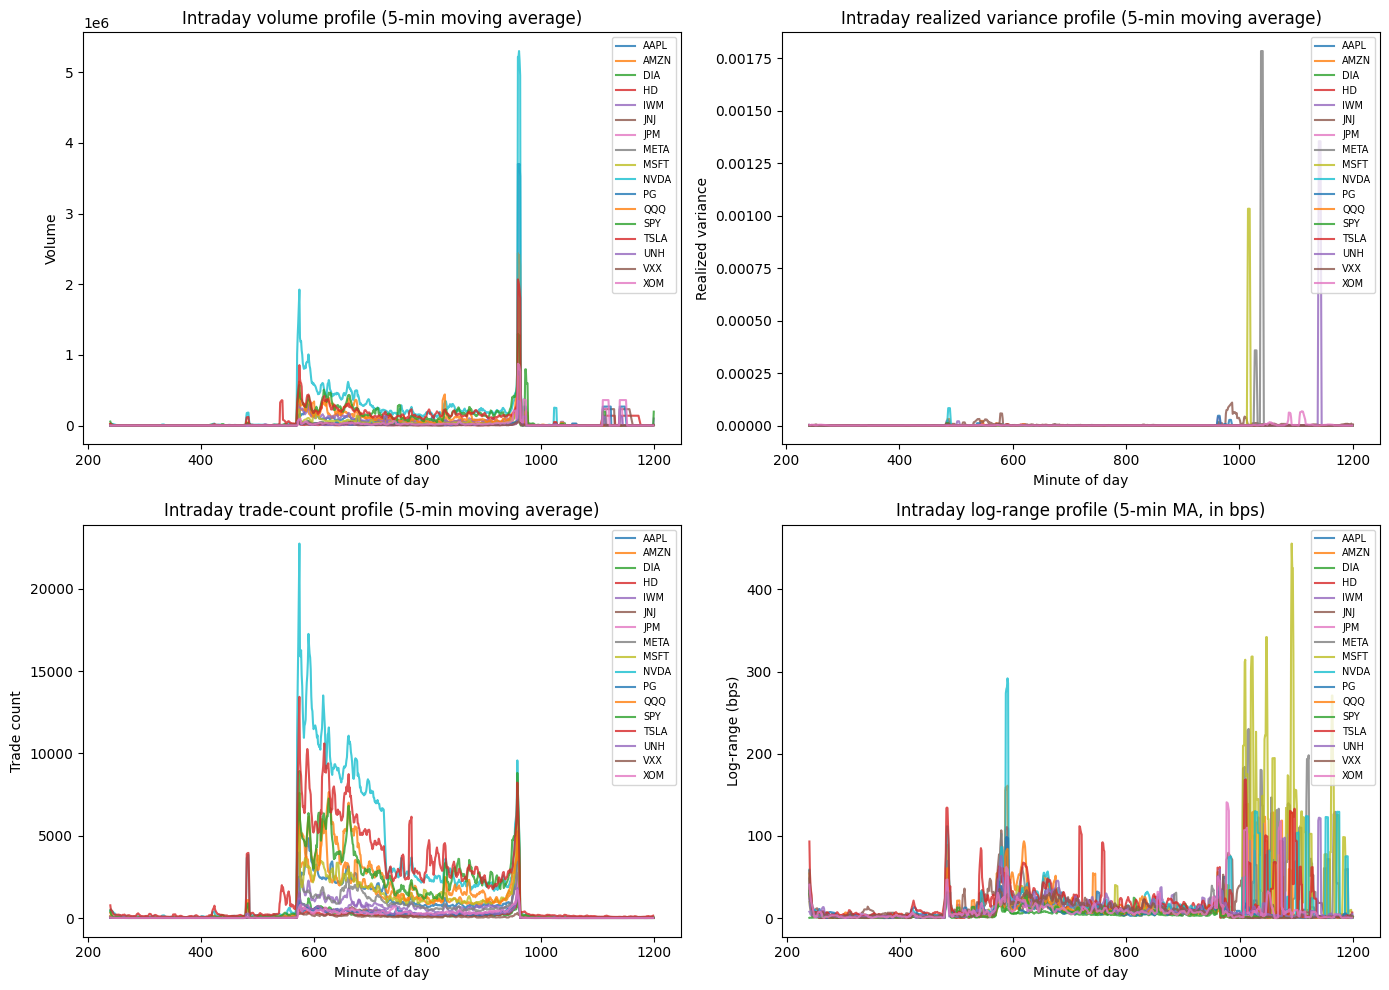

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Volume profile
ax = axes[0, 0]
for symbol, group in bars.groupby('symbol'):
    group = group.sort_values('time_bin')
    ax.plot(group['time_bin'], group['total_volume'].rolling(5, min_periods=1).mean(), label=symbol, alpha=0.8)
ax.set_title('Intraday volume profile (5-min moving average)')
ax.set_xlabel('Minute of day')
ax.set_ylabel('Volume')
ax.legend(loc='upper right', fontsize=7)

# Volatility profile
ax = axes[0, 1]
for symbol, group in bars.groupby('symbol'):
    group = group.sort_values('time_bin')
    ax.plot(group['time_bin'], group['realized_var'].rolling(5, min_periods=1).mean(), label=symbol, alpha=0.8)
ax.set_title('Intraday realized variance profile (5-min moving average)')
ax.set_xlabel('Minute of day')
ax.set_ylabel('Realized variance')
ax.legend(loc='upper right', fontsize=7)

# Trade count profile
ax = axes[1, 0]
for symbol, group in bars.groupby('symbol'):
    group = group.sort_values('time_bin')
    ax.plot(group['time_bin'], group['trade_count'].rolling(5, min_periods=1).mean(), label=symbol, alpha=0.8)
ax.set_title('Intraday trade-count profile (5-min moving average)')
ax.set_xlabel('Minute of day')
ax.set_ylabel('Trade count')
ax.legend(loc='upper right', fontsize=7)

# Spread profile (range as proxy)
ax = axes[1, 1]
for symbol, group in bars.groupby('symbol'):
    group = group.sort_values('time_bin')
    ax.plot(group['time_bin'], group['minute_range'].rolling(5, min_periods=1).mean() * 10000, label=symbol, alpha=0.8)
ax.set_title('Intraday log-range profile (5-min MA, in bps)')
ax.set_xlabel('Minute of day')
ax.set_ylabel('Log-range (bps)')
ax.legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.show()

## 7. Feature engineering ideas from consolidated trades

The raw trade file supports a wide range of features:

### Volume features
- **Total volume** and **dollar volume** per minute / hour / day.
- **Trade count** and **average trade size**.
- **Volume profile** — 390-dimensional vector of minute-by-minute volume.
- **Time-of-day decomposition** — open vs. close vs. midday activity.

### Volatility / price features
- **Minute returns** and **realized variance**.
- **High-low range** and **VWAP**.
- **Intraday volatility profile** — similar to volume profile but with squared returns.

### Microstructure features (when combined with BBO/NBBO)
- **Effective spread** — `2 * |trade_price - mid_price| / mid_price`.
- **Price impact** — signed volume regressed on future returns.
- **Trade signing** — Lee-Ready / tick test for buyer vs. seller initiated.
- **Order flow imbalance** — buy-initiated minus sell-initiated volume.

### Cross-sectional features
- **Relative volume** — symbol volume relative to its rolling median.
- **Relative volatility** — symbol volatility relative to its sector / ETF.
- **Market-share** — fraction of volume executed at each venue.

For a first nonlinear-dimension-reduction experiment, the **volume profile** or **volatility profile** is the cleanest starting point: each symbol-day is a 390-dimensional vector, and you can compare PCA vs. Isomap / UMAP / Diffusion maps on those vectors.

## 8. Demo: PCA vs. Isomap on intraday volume curves

This is a small illustration of the idea the walkthrough notebook proposed: treat each symbol as an intraday curve and compare linear vs. nonlinear embeddings.

**Caveat:** We only have one trading day here, so this is purely a method demo. A real test would need many symbol-days.

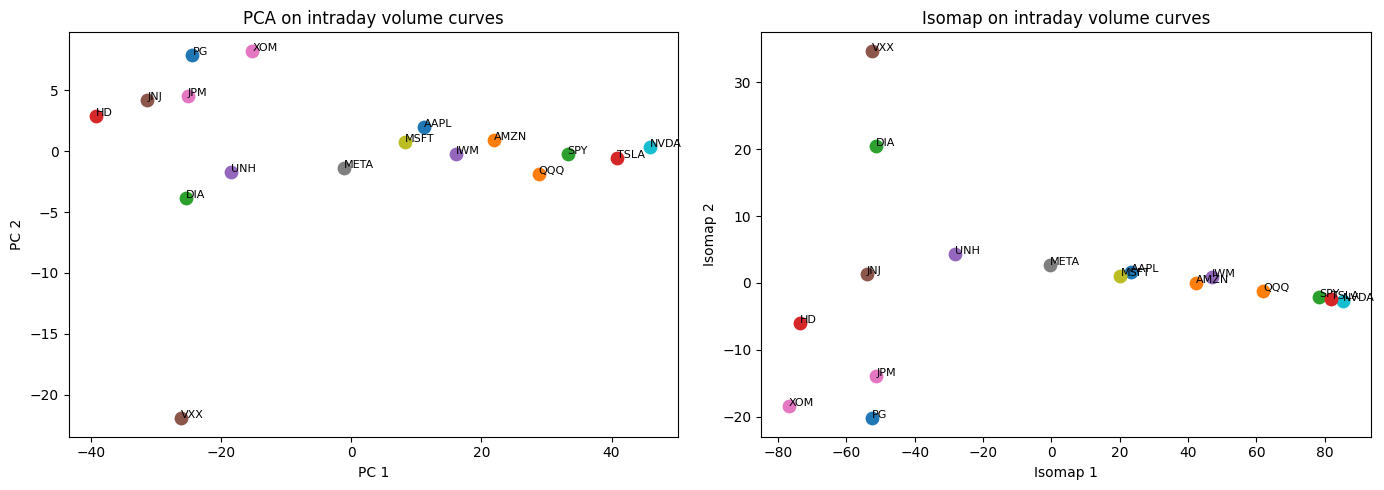

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap

volume_curve = bars.pivot_table(index='symbol', columns='time_bin', values='total_volume', fill_value=0)
X = np.log1p(volume_curve.values)
X_scaled = StandardScaler().fit_transform(X)

pca_emb = PCA(n_components=2, svd_solver='full').fit_transform(X_scaled)
isomap_emb = Isomap(n_neighbors=min(3, len(volume_curve) - 1), n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, symbol in enumerate(volume_curve.index):
    axes[0].scatter(pca_emb[i, 0], pca_emb[i, 1], s=80)
    axes[0].text(pca_emb[i, 0], pca_emb[i, 1], symbol, fontsize=8)
    axes[1].scatter(isomap_emb[i, 0], isomap_emb[i, 1], s=80)
    axes[1].text(isomap_emb[i, 0], isomap_emb[i, 1], symbol, fontsize=8)
axes[0].set_title('PCA on intraday volume curves')
axes[1].set_title('Isomap on intraday volume curves')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[1].set_xlabel('Isomap 1')
axes[1].set_ylabel('Isomap 2')
plt.tight_layout()
plt.show()

## 9. Main takeaways

1. `EQY_US_ALL_TRADE_20260102.gz` is a **consolidated full-day trade file** with one row per executed print, nanosecond timestamps, and venue/source metadata.
2. From this file alone we can build symbol-minute bars with volume, VWAP, returns, realized variance, and dollar volume.
3. The intraday volume and volatility profiles are natural high-dimensional objects for a **PCA vs. nonlinear DR** experiment.
4. To make the experiment real, we need **more than one day** — the NYSE sample site has four sample dates, and the actual TAQ product has full history.
5. The next level of richness comes from combining trades with **NBBO/BBO quotes** to compute spreads, effective spreads, and order-flow imbalance.